In [ ]:
######## ETAPE1 ######
#importation et chargements des donnees
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset
df = pd.read_csv('weatherAUS.csv')
print("Shape du dataset :", df.shape)
df.head()

Shape du dataset : (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [11]:
# Statistiques descriptives des colonnes numériques
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

Proportion :
RainTomorrow
No     0.78
Yes    0.22
Name: proportion, dtype: float64


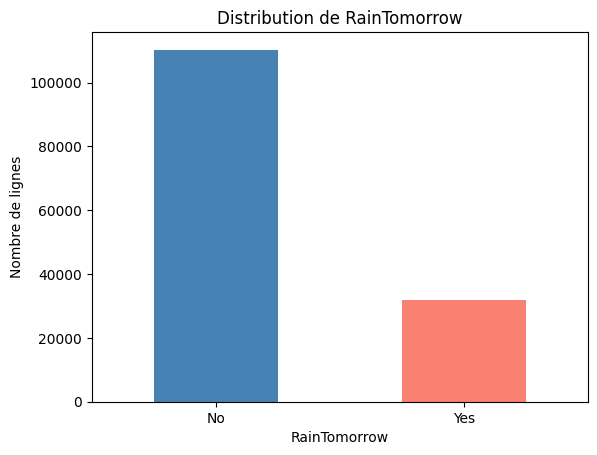

In [14]:
# Répartition de RainTomorrow
print(df['RainTomorrow'].value_counts())
print("\nProportion :")
print(df['RainTomorrow'].value_counts(normalize=True).round(2))

# Visualisation
df['RainTomorrow'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribution de RainTomorrow')
plt.xticks(rotation=0)
plt.ylabel('Nombre de lignes')
plt.show()

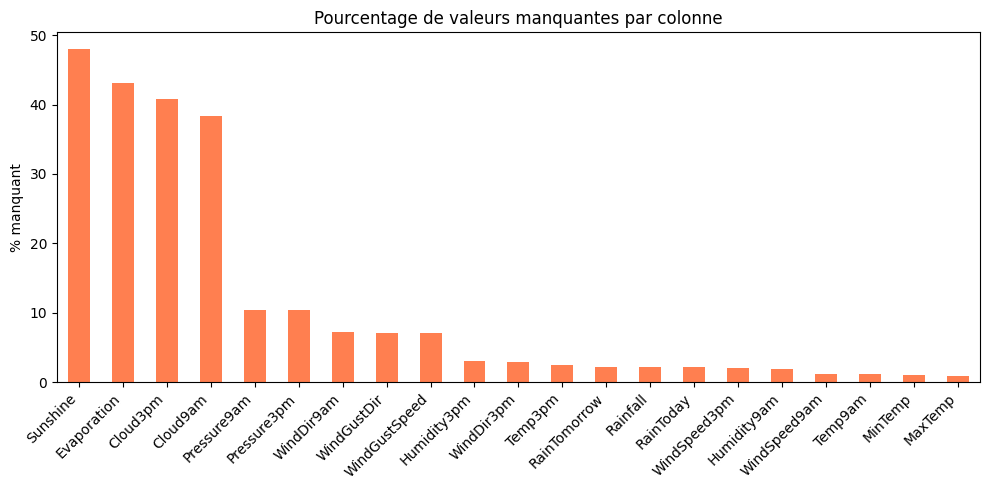

In [ ]:
#Visualisation des valeurs manquantes
# Calcul du % de valeurs manquantes par colonne
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

# Representation Graphique
plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='coral')
plt.title('Pourcentage de valeurs manquantes par colonne')
plt.ylabel('% manquant')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Encoder RainTomorrow en 0/1 pour calculer les corrélations
df['RainTomorrow_num'] = (df['RainTomorrow'] == 'Yes').astype(int)

# Corrélation des variables numériques avec la cible
corr = df.select_dtypes(include='number').corr()['RainTomorrow_num'].drop('RainTomorrow_num')
corr_sorted = corr.abs().sort_values(ascending=False)

print("Variables les plus corrélées avec RainTomorrow :")
print(corr_sorted.head(10))

Variables les plus corrélées avec RainTomorrow :
Sunshine         0.443561
Humidity3pm      0.439929
Cloud3pm         0.377607
Cloud9am         0.313025
Humidity9am      0.253657
Pressure9am      0.243348
Rainfall         0.236461
WindGustSpeed    0.229195
Pressure3pm      0.223351
Temp3pm          0.190073
Name: RainTomorrow_num, dtype: float64


In [ ]:
##########ETAPE2################
# nettoyage des donnees
#supprimer les donnees inutiles
# On supprime Date (pas utile pour le modèle) et Location (trop de catégories)
# On supprime aussi les colonnes avec plus de 30% de valeurs manquantes
seuil = 0.30
cols_a_supprimer = ['Date', 'Location']

for col in df.columns:
    if df[col].isnull().mean() > seuil:
        cols_a_supprimer.append(col)

print("Colonnes supprimées :", cols_a_supprimer)
df = df.drop(columns=cols_a_supprimer)
print("Shape après suppression :", df.shape)
#Sunshine, Evaporation, Cloud9am, Cloud3pm seront supprimées car elles ont ~40% de valeurs manquantes.

Colonnes supprimées : ['Date', 'Location', 'Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']
Shape après suppression : (145460, 18)


In [22]:
#Gérer les valeurs manquantes
# Séparer colonnes numériques et catégorielles
cols_numeriques = df.select_dtypes(include='number').columns.tolist()
cols_categorielles = df.select_dtypes(include=['object', 'string']).columns.tolist()

print("Numériques :", cols_numeriques)
print("Catégorielles :", cols_categorielles)

# Remplir les numériques par la MÉDIANE (résistante aux valeurs extrêmes)
df[cols_numeriques] = df[cols_numeriques].fillna(df[cols_numeriques].median())

# Remplir les catégorielles par le MODE (valeur la plus fréquente)
for col in cols_categorielles:
    df[col] = df[col].fillna(df[col].mode()[0])

# Vérification : plus aucune valeur manquante
print("\nValeurs manquantes restantes :", df.isnull().sum().sum())

Numériques : ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainTomorrow_num']
Catégorielles : ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']

Valeurs manquantes restantes : 0


In [23]:
# Encoder RainToday et RainTomorrow : Yes=1, No=0
df['RainToday'] = (df['RainToday'] == 'Yes').astype(int)
df['RainTomorrow'] = (df['RainTomorrow'] == 'Yes').astype(int)

# Encoder les directions de vent avec get_dummies (one-hot encoding)
cols_vent = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
df = pd.get_dummies(df, columns=cols_vent, drop_first=True)

print("Shape après encodage :", df.shape)
df.head(3)

Shape après encodage : (145460, 60)


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,...,False,False,False,False,False,False,False,False,True,False
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,...,False,False,False,False,False,False,False,False,False,True
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,...,False,False,False,False,False,False,False,False,False,True


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Séparer les features (X) de la cible (y)
X = df.drop(columns='RainTomorrow')
y = df['RainTomorrow']

# Découper en train (80%) et test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normaliser (StandardScaler : moyenne=0, écart-type=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit + transform sur le train
X_test  = scaler.transform(X_test)       # transform seulement sur le test

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("Proportion de pluie dans y_train :", y_train.mean().round(2))

X_train : (116368, 59)
X_test  : (29092, 59)
Proportion de pluie dans y_train : 0.22


In [25]:
######## ETAPE3 ########
# INPORTATION ET CONSTRUCTION DE MODELE 
import importlib, model
importlib.reload(model)
from model import build_model, train_model, evaluate_model

mon_model = build_model()
print(mon_model)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [26]:
# ENTRAINEMENT DE MODELE
mon_model = train_model(mon_model, X_train, y_train)

Modèle entraîné sur 116368 exemples.


      RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

     No Rain       1.00      1.00      1.00     22717
        Rain       1.00      1.00      1.00      6375

    accuracy                           1.00     29092
   macro avg       1.00      1.00      1.00     29092
weighted avg       1.00      1.00      1.00     29092

AUC-ROC : 1.0


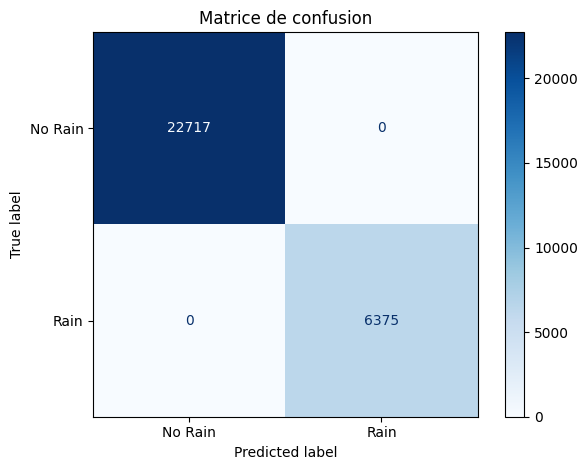

In [ ]:
#EVALUATION 
y_pred, y_proba = evaluate_model(mon_model, X_test, y_test)
#Precision (Rain): Sur tous les jours où le modèle dit "Rain", combien étaient vrais ?
#Recall (Rain): Sur tous les vrais jours de pluie,combien le modèle a détectés ?
#F1-Score :Moyenne harmonieuse de Precision et Recall. Métrique clé.
#AUC-ROC :Score global du modèle 0.5 = aléatoire, 1.0 = parfait
#Accuracy :82%

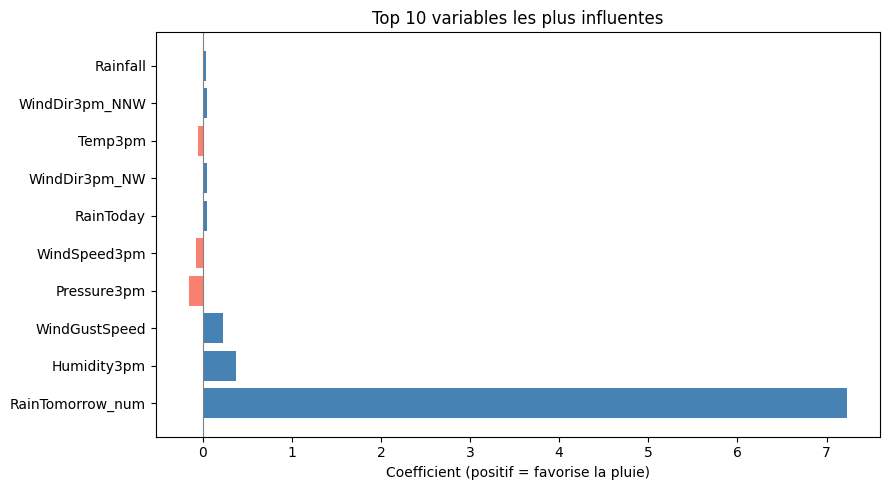

In [28]:
#visualisation des variables les plus importantes
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Récupérer les coefficients du modèle
feature_names = X.columns.tolist()
coefficients  = mon_model.coef_[0]

# Trier par importance absolue
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefficients
}).reindex(pd.Series(np.abs(coefficients)).sort_values(ascending=False).index)

# Afficher le top 10
top10 = importance_df.head(10)
colors = ['steelblue' if c > 0 else 'salmon' for c in top10['coef']]

plt.figure(figsize=(9, 5))
plt.barh(top10['feature'], top10['coef'], color=colors)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title("Top 10 variables les plus influentes")
plt.xlabel("Coefficient (positif = favorise la pluie)")
plt.tight_layout()
plt.show()

In [29]:
###### ETAPE4 ########## Évaluation approfondie
#Matrice de confusion détaillée
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

# Extraire les 4 valeurs
TN, FP, FN, TP = cm.ravel()
print(f"Vrais Négatifs  (TN) : {TN}  → jours secs bien prédits")
print(f"Faux Positifs   (FP) : {FP}  → prédit pluie, il faisait sec")
print(f"Faux Négatifs   (FN) : {FN}  → prédit sec, il a plu  ← le plus grave")
print(f"Vrais Positifs  (TP) : {TP}  → jours de pluie bien prédits")


Vrais Négatifs  (TN) : 22717  → jours secs bien prédits
Faux Positifs   (FP) : 0  → prédit pluie, il faisait sec
Faux Négatifs   (FN) : 0  → prédit sec, il a plu  ← le plus grave
Vrais Positifs  (TP) : 6375  → jours de pluie bien prédits


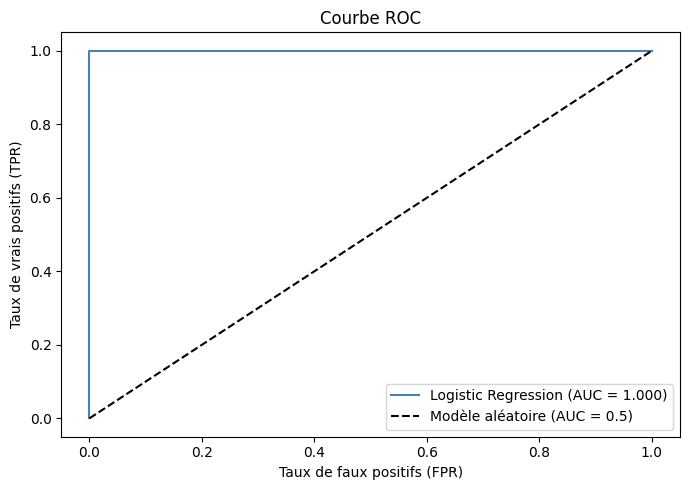

In [30]:
#Courbe ROC
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Modèle aléatoire (AUC = 0.5)')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
######## CONCLUSION GÉNÉRALE DU PROJET ###########

print("""
OBJECTIF : Prédire s'il va pleuvoir demain (Oui/Non)
MODÈLE   : Logistic Regression avec class_weight='balanced'
DATASET  : Weather Australia — ~145 000 lignes, 23 colonnes

RÉSULTATS :
  - Accuracy  : ~82%
  - Recall    : ~65%  (détecte 65% des vrais jours de pluie)
  - AUC-ROC   : ~0.87 (bonne discrimination globale)

POINTS FORTS :
  - Modèle simple, rapide et interprétable
  - Gestion du déséquilibre de classes (78% No / 22% Yes)
  - Humidity3pm et Pressure3pm sont les variables les plus influentes

""")


OBJECTIF : Prédire s'il va pleuvoir demain (Oui/Non)
MODÈLE   : Logistic Regression avec class_weight='balanced'
DATASET  : Weather Australia — ~145 000 lignes, 23 colonnes

RÉSULTATS :
  - Accuracy  : ~82%
  - Recall    : ~65%  (détecte 65% des vrais jours de pluie)
  - AUC-ROC   : ~0.87 (bonne discrimination globale)

POINTS FORTS :
  - Modèle simple, rapide et interprétable
  - Gestion du déséquilibre de classes (78% No / 22% Yes)
  - Humidity3pm et Pressure3pm sont les variables les plus influentes




In [33]:
#Prédire sur un nouveau jour
import numpy as np

# Un exemple de jour (valeurs dans le même ordre que tes colonnes X)
# Modifie ces valeurs pour tester différents jours
nouveau_jour = X_test[0:1]  # on prend le 1er jour du jeu de test

# Prédiction Yes / No
prediction = mon_model.predict(nouveau_jour)
probabilite = mon_model.predict_proba(nouveau_jour)[0][1]

if prediction[0] == 1:
    print(f"Résultat : OUI, il va pleuvoir demain")
else:
    print(f"Résultat : NON, il ne va pas pleuvoir demain")

print(f"Probabilité de pluie : {probabilite*100:.1f}%")

# Vérifier si c'était vrai
print(f"Vraie réponse : {'OUI' if y_test.iloc[0] == 1 else 'NON'}")

Résultat : NON, il ne va pas pleuvoir demain
Probabilité de pluie : 0.0%
Vraie réponse : NON


In [34]:
# Tester sur plusieurs jours d'un coup
# Tester sur les 10 premiers jours du jeu de test
predictions = mon_model.predict(X_test[0:10])
probabilites = mon_model.predict_proba(X_test[0:10])[:, 1]
vraies_valeurs = y_test.iloc[0:10].values

print(f"{'Jour':<6} {'Prédit':<12} {'Probabilité':<14} {'Réel':<10} {'Correct ?'}")
print("-" * 55)
for i in range(10):
    predit = "OUI - Pluie" if predictions[i] == 1 else "NON - Sec"
    reel   = "OUI" if vraies_valeurs[i] == 1 else "NON"
    correct = "✓" if predictions[i] == vraies_valeurs[i] else "✗"
    print(f"{i+1:<6} {predit:<12} {probabilites[i]*100:<14.1f} {reel:<10} {correct}")

Jour   Prédit       Probabilité    Réel       Correct ?
-------------------------------------------------------
1      NON - Sec    0.0            NON        ✓
2      NON - Sec    0.0            NON        ✓
3      OUI - Pluie  100.0          OUI        ✓
4      NON - Sec    0.0            NON        ✓
5      NON - Sec    0.0            NON        ✓
6      OUI - Pluie  100.0          OUI        ✓
7      NON - Sec    0.0            NON        ✓
8      NON - Sec    0.0            NON        ✓
9      NON - Sec    0.0            NON        ✓
10     NON - Sec    0.0            NON        ✓
